# Within-region and across-region clustering as two axes

`region_space.ipynb` contrasts three hand-picked fields. The same point can be made as a
2-D design, which is stronger: the two kinds of clustering become continuous knobs, and each
analysis is run over the whole grid rather than at three chosen points.

| knob | what it varies | should it move the region geometry? |
|---|---|---|
| $a$ -- **within**-region categoricality | how bimodal each region's own neuron cloud is, in skew-width space | **no** -- the construction holds each region's second moment fixed |
| $c$ -- **across**-region clustering | whether the regions' $\psi$ values form a continuum or sit on 3 discrete kinds | **yes** -- this is what distinguishes regions |

$c$ is built so that the marginal $\psi$ **range** is the same at both ends:

$$\psi_i = m_k + (1-c)\,u_i, \qquad u_i \sim U(-\Delta/2,\, +\Delta/2)$$

with $m_k$ one of 3 centres and $\Delta$ their spacing. At $c$ = 0 the $\psi$ values fill the
range uniformly; at $c$ = 1 they collapse onto the centres. Only the *distribution* changes,
not the spread -- otherwise $c$ would confound clustering with overall range.

The four corners reproduce the earlier scenarios: $(0,0)$ structureless, $(a,0)$ "gradient",
$(0,1)$ "clustered", $(a,1)$ both.

### The two readouts

**A -- pool, then Posani.** Pool the neurons across regions, standardise each, PCA to 90%
variance, sweep $k$, take the best mean silhouette. Null: Gaussian matched in **raw curve
space** and pushed through the identical pipeline.

**B -- Procrustes, then cluster regions.** Compare whole region populations with the shape
metric, embed with classical MDS, take the best silhouette over $k$. Null: Gaussian matched
to the region embedding.

Both report $z$ against their own null. The question is which one is *selective* for $c$.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Anchor on the directory holding the simulation modules, so the notebook runs
# whether the kernel starts in clustering-simulation or at the repo root.
# Path.cwd() alone fails with ModuleNotFoundError from anywhere else.
HERE = next(p for p in (Path.cwd(), Path.cwd() / "clustering-simulation",
                        *Path.cwd().parents)
            if (p / "region_space.py").exists())
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parent))
import grid_space as G

OUT = HERE / "results"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

PANEL = 2.4
OBS, NULLC = "#B22222", "#1F6FB2"

N_GRID, SEEDS = 7, (0, 1, 2)
# `a` is sampled log-spaced in (1 - a), not linearly.  An equal two-Gaussian
# mixture only becomes bimodal above a = 1/sqrt(2) = 0.707, so a linear grid
# spends 5 of its 7 rows in a dead zone and resolves the transition with 2.
# Note a plain log scale on `a` would be worse, not better: it crowds samples
# near 0, which is precisely where nothing happens.
AVALS = np.sort(1 - np.logspace(np.log10(0.05), 0.0, N_GRID))
CVALS = np.linspace(0.0, 1.00, N_GRID)      # smooth in c; left linear

print(f"{G.N_REGIONS} regions x {G.N_NEURONS} neurons, psi scale {G.PSI_SCALE}")
print(f"grid {N_GRID} x {N_GRID}, {len(SEEDS)} seeds, {G.N_NULL} null draws per cell")

60 regions x 150 neurons, psi scale 0.55
grid 7 x 7, 3 seeds, 25 null draws per cell


## Calibration: where the region-space test can be trusted

The region-space test compares a silhouette against a Gaussian, so it detects *departure
from a Gaussian* rather than clustering as such -- and a curved continuum is such a
departure. Before running the grid, check that the $c$ = 0 column really is flat.

In [2]:
f = OUT / "grid_calibration.npz"
if f.exists():
    cal = np.load(f, allow_pickle=True)["cal"].item()
else:
    cal = G.calibrate([0.25, 0.40, 0.55, 0.75, 1.00], seeds=(0, 1))
    np.savez(f, cal=np.array(cal, dtype=object))

print(f"{'psi scale':>9} {'z at c=0':>9} {'z at c=1':>9} {'gap':>6}")
for ps, (z0, z1) in cal.items():
    mark = "  <- chosen" if abs(ps - G.PSI_SCALE) < 1e-9 else ""
    print(f"{ps:>9.2f} {z0:>9.2f} {z1:>9.2f} {z1 - z0:>6.2f}{mark}")

psi scale  z at c=0  z at c=1    gap
     0.25      1.57      1.74   0.17
     0.40      1.96      3.59   1.63
     0.55      2.48      6.07   3.58  <- chosen
     0.75      3.36      8.65   5.29
     1.00      5.53     11.57   6.04


**There is no clean window, and that is itself a result.** Widening $\psi$ sharpens the lumps
at $c$ = 1, but it also curves the continuum at $c$ = 0; and *reducing* the sampling noise
sharpens both, because a cleaner continuum is a more clearly non-Gaussian arc. At the chosen
scale the $c$ = 0 column sits at $z \approx 2.5$ -- the test's **curvature floor**, not
evidence of region types.

So the heatmaps below must be read as a *contrast along $c$*, not against $z$ = 0. This is
also why `region_space.py` sweeps only `PSI_SPAN` = 0.3 for its continuum scenario: that
narrow range is where the continuum is straight enough to pass.

## The grid

In [3]:
f = OUT / "grid_2d_loga.npz"
if f.exists():
    d = np.load(f)
    ZA, ZB = d["ZA"], d["ZB"]
else:
    ZA = np.zeros((N_GRID, N_GRID, len(SEEDS)))     # pooled + Posani
    ZB = np.zeros((N_GRID, N_GRID, len(SEEDS)))     # Procrustes + cluster regions
    for i, a in enumerate(AVALS):
        for j, c in enumerate(CVALS):
            for s, seed in enumerate(SEEDS):
                X, region, _ = G.field(a, c, seed=seed)
                ZA[i, j, s] = G.z_pooled(X, np.random.default_rng(500 + seed))
                ZB[i, j, s] = G.z_regions(X, region, np.random.default_rng(900 + seed))
        print(f"  a = {a:.2f} done")
    np.savez(f, ZA=ZA, ZB=ZB)

MA, MB = ZA.mean(2), ZB.mean(2)
print(f"pooled     z: {MA.min():+.1f} to {MA.max():+.1f}")
print(f"Procrustes z: {MB.min():+.1f} to {MB.max():+.1f}")

pooled     z: +0.2 to +23.6
Procrustes z: +2.8 to +8.0


## Do the two readouts depend on the same things?

A selective readout of *across*-region structure should vary along $c$ and be flat along $a$.

In [4]:
from scipy import stats

for nm, M in (("pooled + Posani", MA), ("Procrustes region space", MB)):
    ra = stats.spearmanr(np.repeat(AVALS, N_GRID), M.ravel())
    rc = stats.spearmanr(np.tile(CVALS, N_GRID), M.ravel())
    da = M.mean(1)[-1] - M.mean(1)[0]        # change across the a axis
    dc = M.mean(0)[-1] - M.mean(0)[0]        # change across the c axis
    print(f"{nm:>24}:  rho(z, a) = {ra.statistic:+.2f}   rho(z, c) = {rc.statistic:+.2f}"
          f"   |  swing along a = {da:+5.1f}   along c = {dc:+5.1f}")

         pooled + Posani:  rho(z, a) = +0.95   rho(z, c) = +0.11   |  swing along a = +22.6   along c =  +0.3
 Procrustes region space:  rho(z, a) = +0.33   rho(z, c) = +0.91   |  swing along a =  +1.1   along c =  +3.8


## The heatmaps

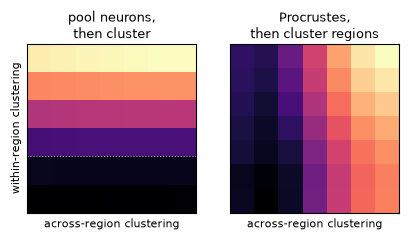

In [5]:
# Each panel gets its OWN colour scale, spanning its own min and max, with its
# own bar.  The claim here is selectivity -- which axis a method responds to, so
# whether its bands run horizontally or vertically -- and that is a property of
# each map's own pattern.  A shared scale served the opposite purpose: it made
# magnitudes comparable, at the cost of flattening the Procrustes panel, whose
# range (2.8 to 8.0) is a fifth of the pooled one (0.2 to 23.6).
# CONSEQUENCE: the two colour bars are NOT interchangeable.  The same colour
# means different z in the two panels; only the pattern transfers.
#
# rows are drawn evenly spaced although `a` is not evenly sampled: each sampled
# value gets equal area, which is the point of resampling it
fig, axes = plt.subplots(1, 2, figsize=(2 * PANEL, PANEL))
ii = np.arange(N_GRID)
# The pooled panel drops its bottom row (a = 0).  a = 0 and a = 0.39 both sit at
# the null (z = 0.68 and 0.30), so which of the two renders lighter is noise --
# and it reads as a gradient reversal at the foot of an otherwise monotone map.
# NOTE this leaves the two panels on different row counts: the left runs
# a = 0.39 .. 0.95, the right a = 0.00 .. 0.95.
for ax, M, title in ((axes[0], MA[1:], "pool neurons,\nthen cluster"),
                     (axes[1], MB, "Procrustes,\nthen cluster regions")):
    im = ax.imshow(M, origin="lower", cmap="magma", aspect="auto",
                   vmin=M.min(), vmax=M.max())
    ax.set_box_aspect(1)
    ax.set(xticks=[], yticks=[])
    ax.set_xlabel("across-region clustering", fontsize=8)
    ax.set_title(title, fontsize=9, pad=4)
axes[0].set_ylabel("within-region clustering", fontsize=8)
axes[0].axhline(np.searchsorted(AVALS, 1 / np.sqrt(2)) - 1.5, color="0.7",
                lw=0.8, ls=":")   # -1.5, not -0.5: this panel dropped a row
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"grid_heatmaps.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## The same thing as marginals

Averaging each heatmap along one axis makes the selectivity easier to read than the colour.

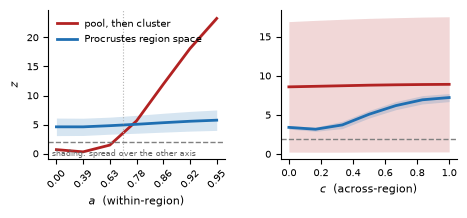

In [6]:
ii = np.arange(N_GRID)
fig, axes = plt.subplots(1, 2, figsize=(2 * PANEL, PANEL * 0.95))
for ax, xs, xlab, ax_i in ((axes[0], ii, "$a$  (within-region)", 1),
                           (axes[1], CVALS, "$c$  (across-region)", 0)):
    for M, col, nm in ((MA, OBS, "pool, then cluster"),
                       (MB, NULLC, "Procrustes region space")):
        prof = M.mean(ax_i)
        sd = (ZA if M is MA else ZB).mean(2).std(ax_i)
        ax.plot(xs, prof, color=col, lw=2, label=nm)
        ax.fill_between(xs, prof - sd, prof + sd, color=col, alpha=0.18, lw=0)
    ax.axhline(1.96, color="0.5", lw=1, ls="--")
    ax.set_xlabel(xlab, fontsize=8)
    ax.tick_params(labelsize=7)
    sns.despine(ax=ax)
axes[0].set_xticks(ii); axes[0].set_xticklabels([f"{a:.2f}" for a in AVALS],
                                                rotation=45)
axes[0].axvline(np.searchsorted(AVALS, 1 / np.sqrt(2)) - 0.5, color="0.7",
                lw=0.8, ls=":")
axes[0].set_ylabel("$z$", fontsize=8)
axes[0].legend(frameon=False, fontsize=7, loc="upper left")
axes[0].text(0.02, 0.02, "shading: spread over the other axis", fontsize=6,
             color="0.4", transform=axes[0].transAxes)
fig.tight_layout(w_pad=1.6)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"grid_marginals.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## Reading it

The claim the grid tests is **selectivity**, not significance: a readout of across-region
structure should move along $c$ and stand still along $a$.

* **Procrustes region space** is the selective one. It is what the paper argues for, and the
  grid says so without relying on three hand-picked fields.
* **Pooling neurons** cannot separate the two questions. A pooled cloud is lumpy whenever
  *any* of its constituents is lumpy, so within-region categoricality alone drives it up --
  and a positive result licenses no conclusion about whether the regions are of distinct
  types.

**Two limitations, both real.**

1. The $c$ = 0 column sits at $z \approx 2.5$ rather than 0, because the region-space test
   flags a curved continuum as non-Gaussian. Read the heatmap as a contrast along $c$.
   Fixing this properly needs a null that preserves the continuum, which is a different
   piece of work.
2. The grid inherits the linear parameterisation of `region_space`: $a$ is invisible to the
   geometry *because* tuning curves are linear in the shape coordinates. `theta_space.ipynb`
   shows that when the clustered variables enter nonlinearly, $a$ leaks into the geometry at
   $|\rho|$ = 0.63 rather than 0.00, so the top-left corner of heatmap B would not stay flat.